<a href="https://colab.research.google.com/github/kursatkara/MAE_5020_Spring_2026/blob/master/06_Notebook_C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Notebook C — From One Point to Data: Function Approximation and Generalization

## 🎯 Learning Objective

Move from a single training pair to a small dataset and understand a more important question:

> Can a neural network learn a **function** rather than merely reduce the error on one point?

In this notebook, we will:
- construct a small noisy dataset,
- train neural networks of different sizes,
- compare training and testing behavior,
- interpret **underfitting**, **reasonable fitting**, and **overfitting**.

---

## 🧠 Challenge

In Notebooks A and B, the network saw only one input-target pair.

That was useful for understanding:
- forward propagation,
- backpropagation,
- gradient descent dynamics.

But it is not enough for modeling.

In engineering, we usually care about approximating an underlying relationship such as
$$
y = f(x),
$$
not merely matching one sample.

That raises a deeper question:

> When does a trained neural network actually generalize to unseen data?



## 🔹 Problem Setup

We will generate data from a smooth one-dimensional function and then add noise:

$$
y = f(x) + \epsilon,
$$
where $\epsilon$ represents measurement or process noise.

This is a useful first step because it mirrors a common engineering situation:

- there is some underlying physical trend,
- measurements are limited,
- observations are noisy.

We will use a simple target function:
$$
f(x) = x^2.
$$

This choice is intentional:
- it is nonlinear,
- it is easy to visualize,
- it is simple enough that students can focus on the learning behavior.


In [1]:

import torch
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(2)
np.random.seed(2)

plt.rcParams["figure.figsize"] = (7, 4)



## 🔹 Generate a Small Noisy Dataset

We create a modest dataset and then split it into training and testing subsets.

Why split the data?

Because a model should not be judged only by how well it fits the data it has already seen.

A more meaningful evaluation asks:

> Does the model also perform well on data that were not used during training?


In [2]:

# Generate dataset
N = 24
x_all = torch.linspace(-1.2, 1.2, N).unsqueeze(1)
y_true_all = x_all**2
noise = 0.08 * torch.randn_like(x_all)
y_all = y_true_all + noise

# Train/test split
perm = torch.randperm(N)
train_idx = perm[:12]
test_idx = perm[12:]

x_train = x_all[train_idx]
y_train = y_all[train_idx]

x_test = x_all[test_idx]
y_test = y_all[test_idx]

# Sort for cleaner plotting later
def sort_xy(x, y):
    idx = torch.argsort(x[:, 0])
    return x[idx], y[idx]

x_train, y_train = sort_xy(x_train, y_train)
x_test, y_test = sort_xy(x_test, y_test)
x_all_sorted, y_all_sorted = sort_xy(x_all, y_all)
_, y_true_sorted = sort_xy(x_all, y_true_all)

print("Training samples:", len(x_train))
print("Testing samples :", len(x_test))


Training samples: 12
Testing samples : 12


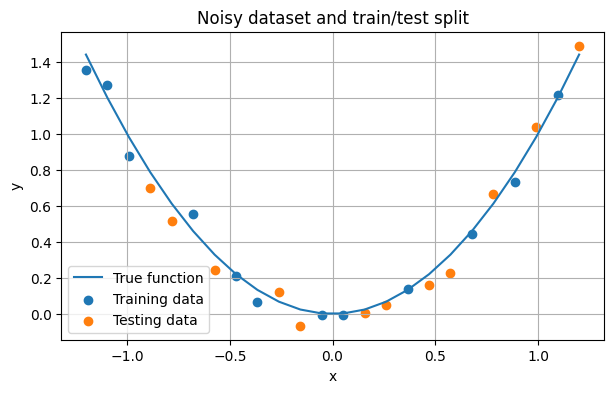

In [3]:

plt.figure()
plt.plot(x_all_sorted.numpy(), y_true_sorted.numpy(), label="True function")
plt.scatter(x_train.numpy(), y_train.numpy(), label="Training data")
plt.scatter(x_test.numpy(), y_test.numpy(), label="Testing data")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Noisy dataset and train/test split")
plt.legend()
plt.grid(True)
plt.show()



## 🔹 What the Network Is Learning

For a dataset
$$
\{(x_i, y_i)\}_{i=1}^N,
$$
we now minimize an average loss such as
$$
L(\theta) = \frac{1}{N}\sum_{i=1}^N \left(\hat{y}_i - y_i\right)^2,
$$
where
$$
\hat{y}_i = f(x_i; \theta).
$$

This is an important conceptual shift.

In Notebook B, the goal was:
- reduce the error on one point.

In this notebook, the goal is:
- identify a nonlinear mapping from data.

That is much closer to real scientific machine learning problems.



## 🔹 A Simple Feedforward Network

We will use a one-hidden-layer neural network:
$$
z^1 = W^1 x + b^1,
$$
$$
a^1 = \phi(z^1),
$$
$$
\hat{y} = W^2 a^1 + b^2.
$$

Notice one change relative to Notebooks A and B:

- we keep the hidden-layer nonlinearity,
- but we use a **linear output layer**.

That is standard for regression problems because the target is continuous and should not be artificially restricted to $(0,1)$.


In [4]:

class SimpleRegressor(torch.nn.Module):
    def __init__(self, hidden_width):
        super().__init__()
        self.fc1 = torch.nn.Linear(1, hidden_width)
        self.fc2 = torch.nn.Linear(hidden_width, 1)

    def forward(self, x):
        a1 = torch.tanh(self.fc1(x))
        y_hat = self.fc2(a1)
        return y_hat

def mse_loss(y_hat, y):
    return torch.mean((y_hat - y)**2)



## 🔹 A Reusable Training Function

To compare model behavior fairly, we will create a reusable training function.

It will record:
- training loss,
- testing loss,
- predictions,
- final model.

This allows us to compare different hidden-layer widths and interpret how model capacity affects the results.


In [5]:

def train_model(hidden_width=5, lr=0.05, epochs=1000):
    torch.manual_seed(10)

    model = SimpleRegressor(hidden_width)
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)

    history = {
        "epoch": [],
        "train_loss": [],
        "test_loss": [],
    }

    for epoch in range(epochs):
        # Training mode
        model.train()

        # Forward on training data
        y_train_hat = model(x_train)
        train_loss = mse_loss(y_train_hat, y_train)

        optimizer.zero_grad()
        train_loss.backward()
        optimizer.step()

        # Evaluation on test data
        model.eval()
        with torch.no_grad():
            y_test_hat = model(x_test)
            test_loss = mse_loss(y_test_hat, y_test)

        history["epoch"].append(epoch)
        history["train_loss"].append(train_loss.item())
        history["test_loss"].append(test_loss.item())

    return model, history



## 🔹 Three Capacity Regimes

We will compare three models:

1. **Small model**: hidden width = 1  
   This may be too limited and can underfit.

2. **Moderate model**: hidden width = 5  
   This is often a reasonable balance for this problem.

3. **Large model**: hidden width = 50  
   This may fit the training data very closely and risk overfitting.

The goal is not to memorize architecture choices.  
The goal is to observe how **model capacity** changes the behavior.


In [6]:

model_small, hist_small = train_model(hidden_width=1, lr=0.05, epochs=1200)
model_medium, hist_medium = train_model(hidden_width=5, lr=0.05, epochs=1200)
model_large, hist_large = train_model(hidden_width=50, lr=0.05, epochs=1200)



## 🔹 Compare Training and Testing Loss

A single loss curve is rarely enough.

We want to compare:
- training loss: how well the model fits what it has seen,
- testing loss: how well the model performs on unseen data.

These two curves together often reveal whether the model is:
- underfitting,
- fitting reasonably,
- overfitting.


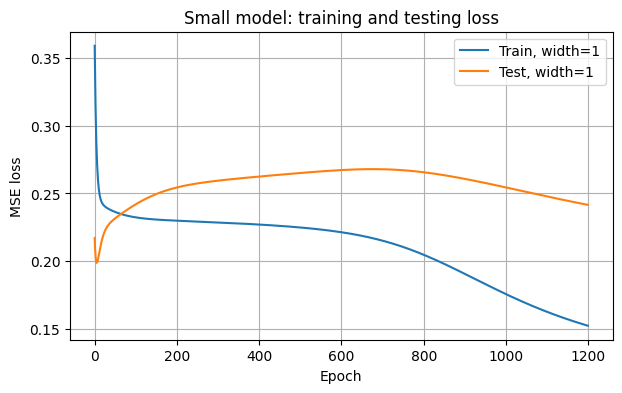

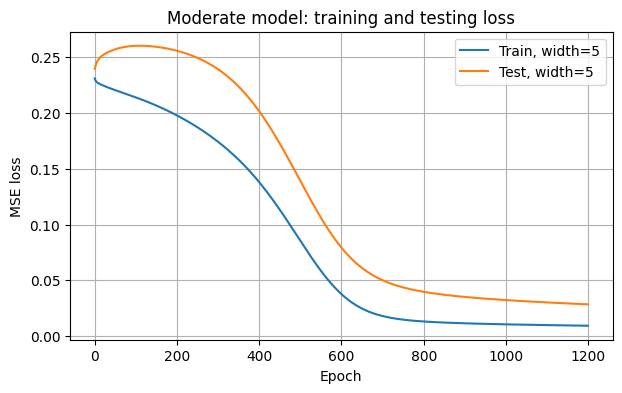

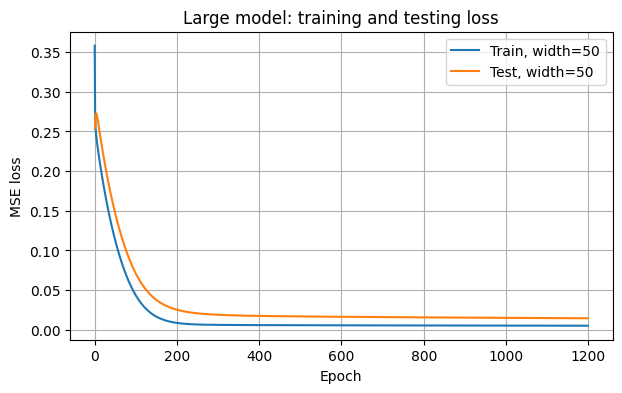

In [7]:

plt.figure()
plt.plot(hist_small["epoch"], hist_small["train_loss"], label="Train, width=1")
plt.plot(hist_small["epoch"], hist_small["test_loss"], label="Test, width=1")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Small model: training and testing loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(hist_medium["epoch"], hist_medium["train_loss"], label="Train, width=5")
plt.plot(hist_medium["epoch"], hist_medium["test_loss"], label="Test, width=5")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Moderate model: training and testing loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(hist_large["epoch"], hist_large["train_loss"], label="Train, width=50")
plt.plot(hist_large["epoch"], hist_large["test_loss"], label="Test, width=50")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Large model: training and testing loss")
plt.legend()
plt.grid(True)
plt.show()



## 🔹 Compare the Learned Functions

Loss curves are useful, but the most intuitive picture is often the function itself.

We now compare:
- the true underlying function,
- the noisy training and testing points,
- the predictions from the three models.

This visualization helps students connect numerical loss values to actual model behavior.


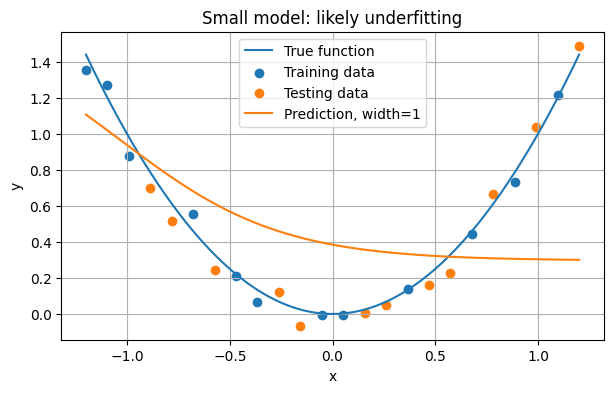

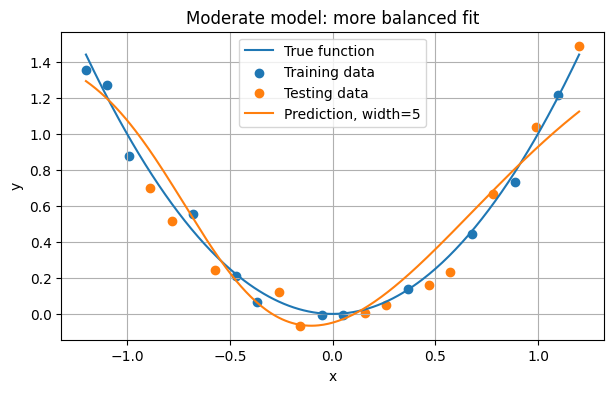

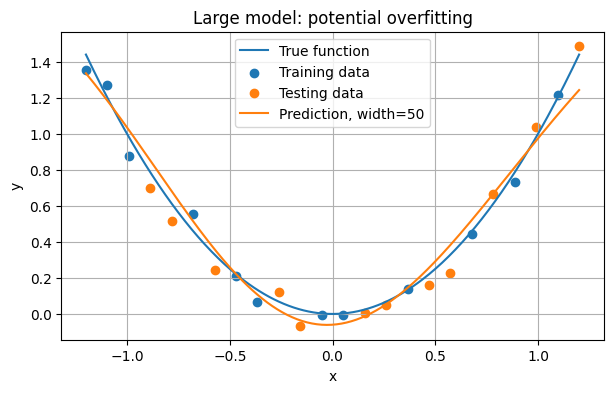

In [8]:

x_plot = torch.linspace(-1.2, 1.2, 300).unsqueeze(1)
y_plot_true = x_plot**2

with torch.no_grad():
    y_plot_small = model_small(x_plot)
    y_plot_medium = model_medium(x_plot)
    y_plot_large = model_large(x_plot)

plt.figure()
plt.plot(x_plot.numpy(), y_plot_true.numpy(), label="True function")
plt.scatter(x_train.numpy(), y_train.numpy(), label="Training data")
plt.scatter(x_test.numpy(), y_test.numpy(), label="Testing data")
plt.plot(x_plot.numpy(), y_plot_small.numpy(), label="Prediction, width=1")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Small model: likely underfitting")
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(x_plot.numpy(), y_plot_true.numpy(), label="True function")
plt.scatter(x_train.numpy(), y_train.numpy(), label="Training data")
plt.scatter(x_test.numpy(), y_test.numpy(), label="Testing data")
plt.plot(x_plot.numpy(), y_plot_medium.numpy(), label="Prediction, width=5")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Moderate model: more balanced fit")
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(x_plot.numpy(), y_plot_true.numpy(), label="True function")
plt.scatter(x_train.numpy(), y_train.numpy(), label="Training data")
plt.scatter(x_test.numpy(), y_test.numpy(), label="Testing data")
plt.plot(x_plot.numpy(), y_plot_large.numpy(), label="Prediction, width=50")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Large model: potential overfitting")
plt.legend()
plt.grid(True)
plt.show()



## 🔍 Sanity Check

At this point, ask the following:

- Is the training loss lower than the testing loss?
- Does the small model fail to capture the curvature of $x^2$?
- Does the large model begin to chase noise in the training data?
- Which model best captures the overall trend without becoming too wiggly?

These checks are more important than any single numeric score.



## 🔹 Interpreting Underfitting and Overfitting

### Underfitting

A model underfits when it is too simple to represent the main structure in the data.

Typical signs:
- training loss remains relatively high,
- testing loss is also high,
- predictions miss the overall trend.

### Overfitting

A model overfits when it starts fitting noise rather than structure.

Typical signs:
- training loss becomes very small,
- testing loss stops improving or gets worse,
- the learned function becomes unnecessarily complicated.

### Reasonable fit

A good model captures the underlying trend without responding excessively to noise.



## 🔹 Why Generalization Matters

In engineering applications, we often train a model using limited data and then ask it to make predictions at new conditions.

That means the real question is not:

> How well did the model fit the training data?

The more important question is:

> How well does the model capture the underlying relationship so that it remains useful on unseen data?

This is why the train/test distinction is fundamental.


In [9]:

def final_losses(history):
    return history["train_loss"][-1], history["test_loss"][-1]

summary = {
    "width=1": final_losses(hist_small),
    "width=5": final_losses(hist_medium),
    "width=50": final_losses(hist_large),
}

for key, (train_l, test_l) in summary.items():
    print(f"{key:8s} | final train loss = {train_l:.6f} | final test loss = {test_l:.6f}")


width=1  | final train loss = 0.152441 | final test loss = 0.241572
width=5  | final train loss = 0.009242 | final test loss = 0.028429
width=50 | final train loss = 0.005165 | final test loss = 0.014577



## 🔹 Reflection Questions

1. Why is it possible for the training loss to decrease while the testing loss does not improve?
2. What features of the plots suggest underfitting?
3. What features suggest overfitting?
4. Why is a linear output layer more appropriate here than a sigmoid output layer?
5. In a real aerospace application, what might the noise term $\epsilon$ represent?

These are the kinds of questions students should be able to discuss after running the notebook.



## 🧠 Engineering Takeaway

A neural network trained on data is solving a nonlinear regression problem:
$$
\hat{y} = f(x; \theta), \qquad \theta^\star = \arg\min_\theta L(\theta).
$$

But successful training is not the same as a successful model.

A useful model must:
- fit the important structure,
- avoid chasing noise,
- perform reasonably on unseen data.

This is the essence of **generalization**.



## 🚀 Next

In the next notebook, we will move to a cleaner and more standard PyTorch workflow:
- `nn.Module`,
- structured training loops,
- best practices such as reproducibility and normalization,
- clearer separation between model definition, training, and evaluation.

The goal will be to scale up the workflow without losing the mathematical understanding developed in the first three notebooks.
